# Exploratory Data Analysis (EDA) - Auto MPG Dataset

This notebook performs comprehensive exploratory data analysis on the Auto MPG dataset including:
- Dataset inspection and statistics
- Missing value analysis
- Correlation analysis
- Distribution plots for all features
- Outlier detection using boxplots
- Pairwise scatter plots for relationships

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fix path to import utils
sys.path.insert(0, os.path.abspath('..'))

from utils.data_loader import AutoMPGDataLoader

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Libraries imported successfully!
NumPy version: 1.26.4
Pandas version: 1.5.3
Matplotlib version: 3.7.2


## Step 1: Load and Clean Data

In [3]:
# Initialize data loader
loader = AutoMPGDataLoader(data_dir='data')

# Download and clean dataset
df_raw = loader.download_dataset()
df_clean = loader.clean_dataset(df_raw)

# Display first few rows
print("\nFirst 5 rows of cleaned dataset:")
print(df_clean.head())

Dataset downloaded successfully to data\auto_mpg_raw.data
Cleaning dataset...

Dataset shape before cleaning: (398, 9)
Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64
Dataset shape after cleaning: (392, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 27.6 KB
None

Dataset Statistics:
              mpg   cylin

## Step 2: Dataset Overview

In [4]:
# Dataset shape
print(f"Dataset shape: {df_clean.shape}")
print(f"Number of samples: {df_clean.shape[0]}")
print(f"Number of features: {df_clean.shape[1]}")

# Data types
print("\nData types:")
print(df_clean.dtypes)

# Missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df_clean.describe())

Dataset shape: (392, 8)
Number of samples: 392
Number of features: 8

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Statistical Summary:
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.0

## Step 3: Correlation Analysis

Saved: images/eda/correlation_heatmap.png


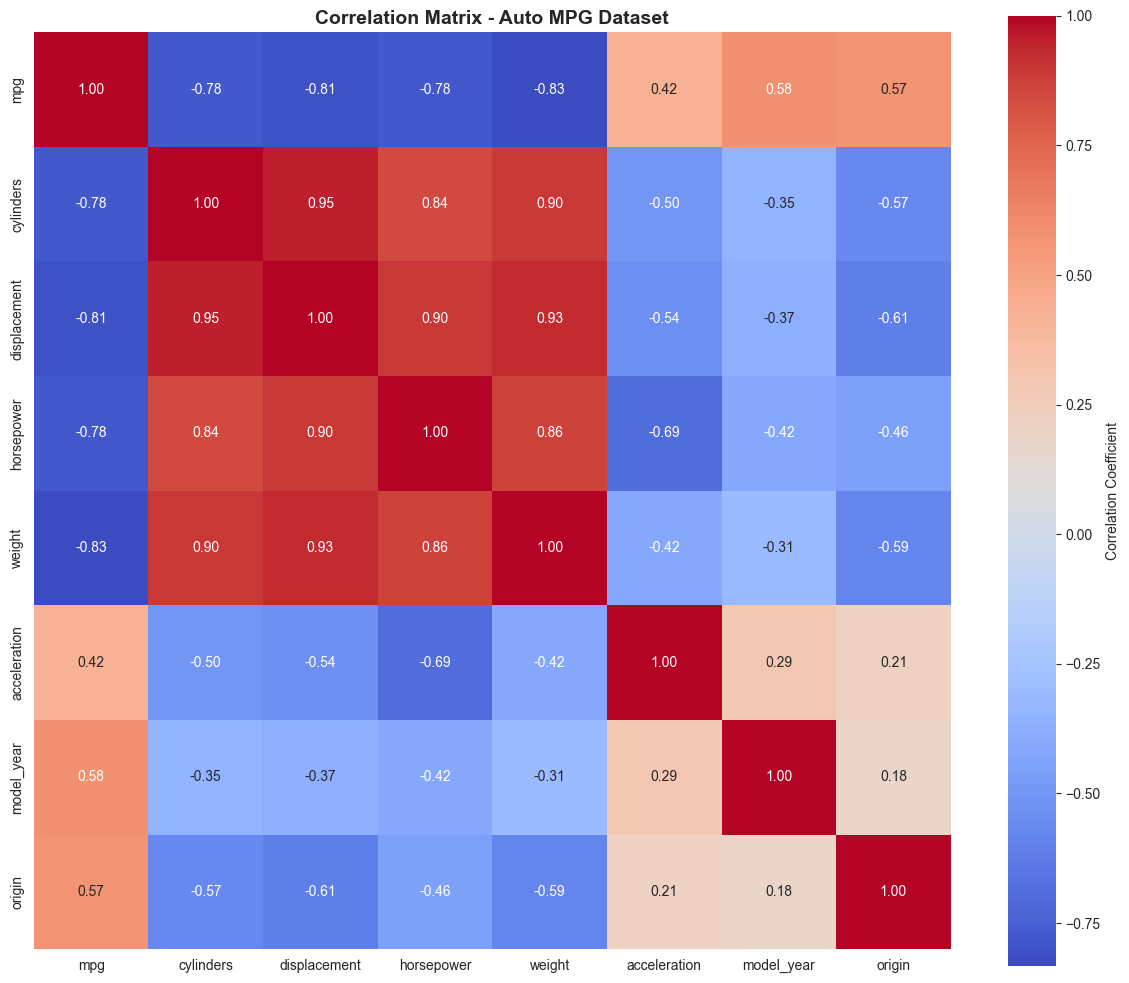


Correlations with MPG (target):
mpg             1.000000
model_year      0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


In [5]:
# Calculate correlation matrix
correlation_matrix = df_clean.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix - Auto MPG Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
os.makedirs('images/eda', exist_ok=True)
plt.savefig('images/eda/correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: images/eda/correlation_heatmap.png")
plt.show()

# Print correlations with target (mpg)
print("\nCorrelations with MPG (target):")
mpg_corr = correlation_matrix['mpg'].sort_values(ascending=False)
print(mpg_corr)

## Step 4: Distribution Plots for All Features

Saved: images/eda/feature_distributions.png


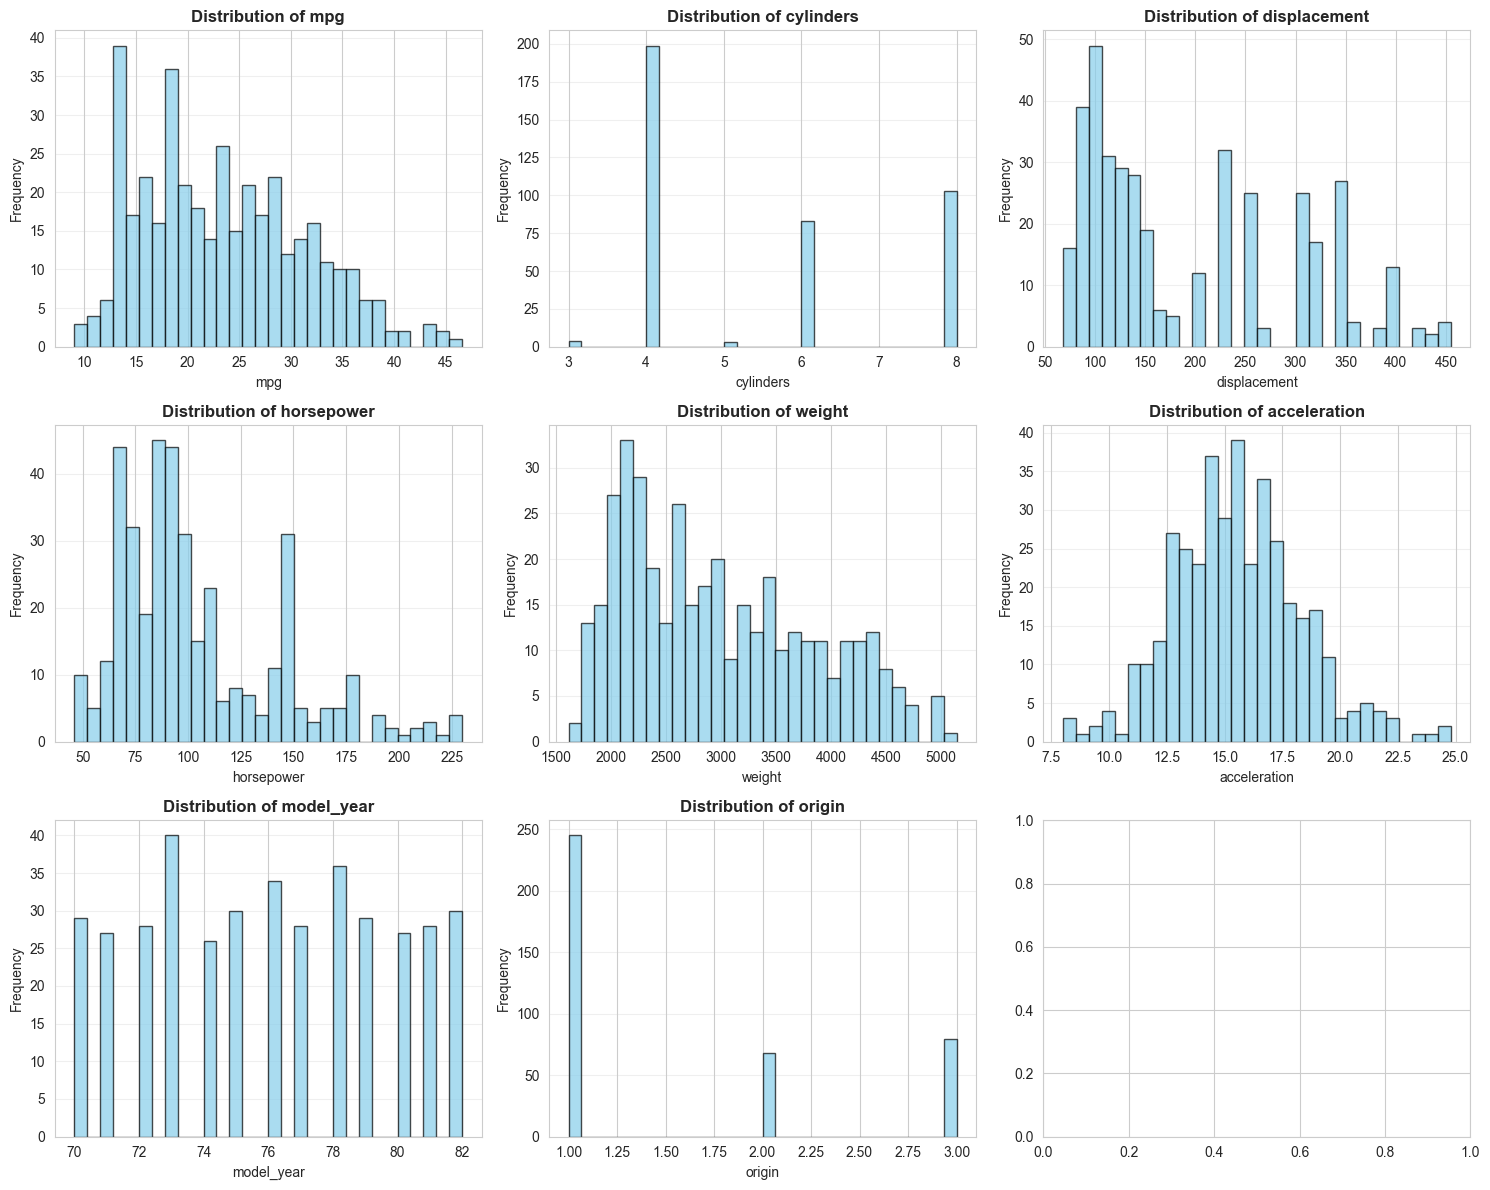

In [6]:
# Plot distributions for all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df_clean.columns):
    axes[idx].hist(df_clean[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/eda/feature_distributions.png', dpi=300, bbox_inches='tight')
print("Saved: images/eda/feature_distributions.png")
plt.show()

## Step 5: Boxplots for Outlier Detection

Saved: images/eda/feature_boxplots.png


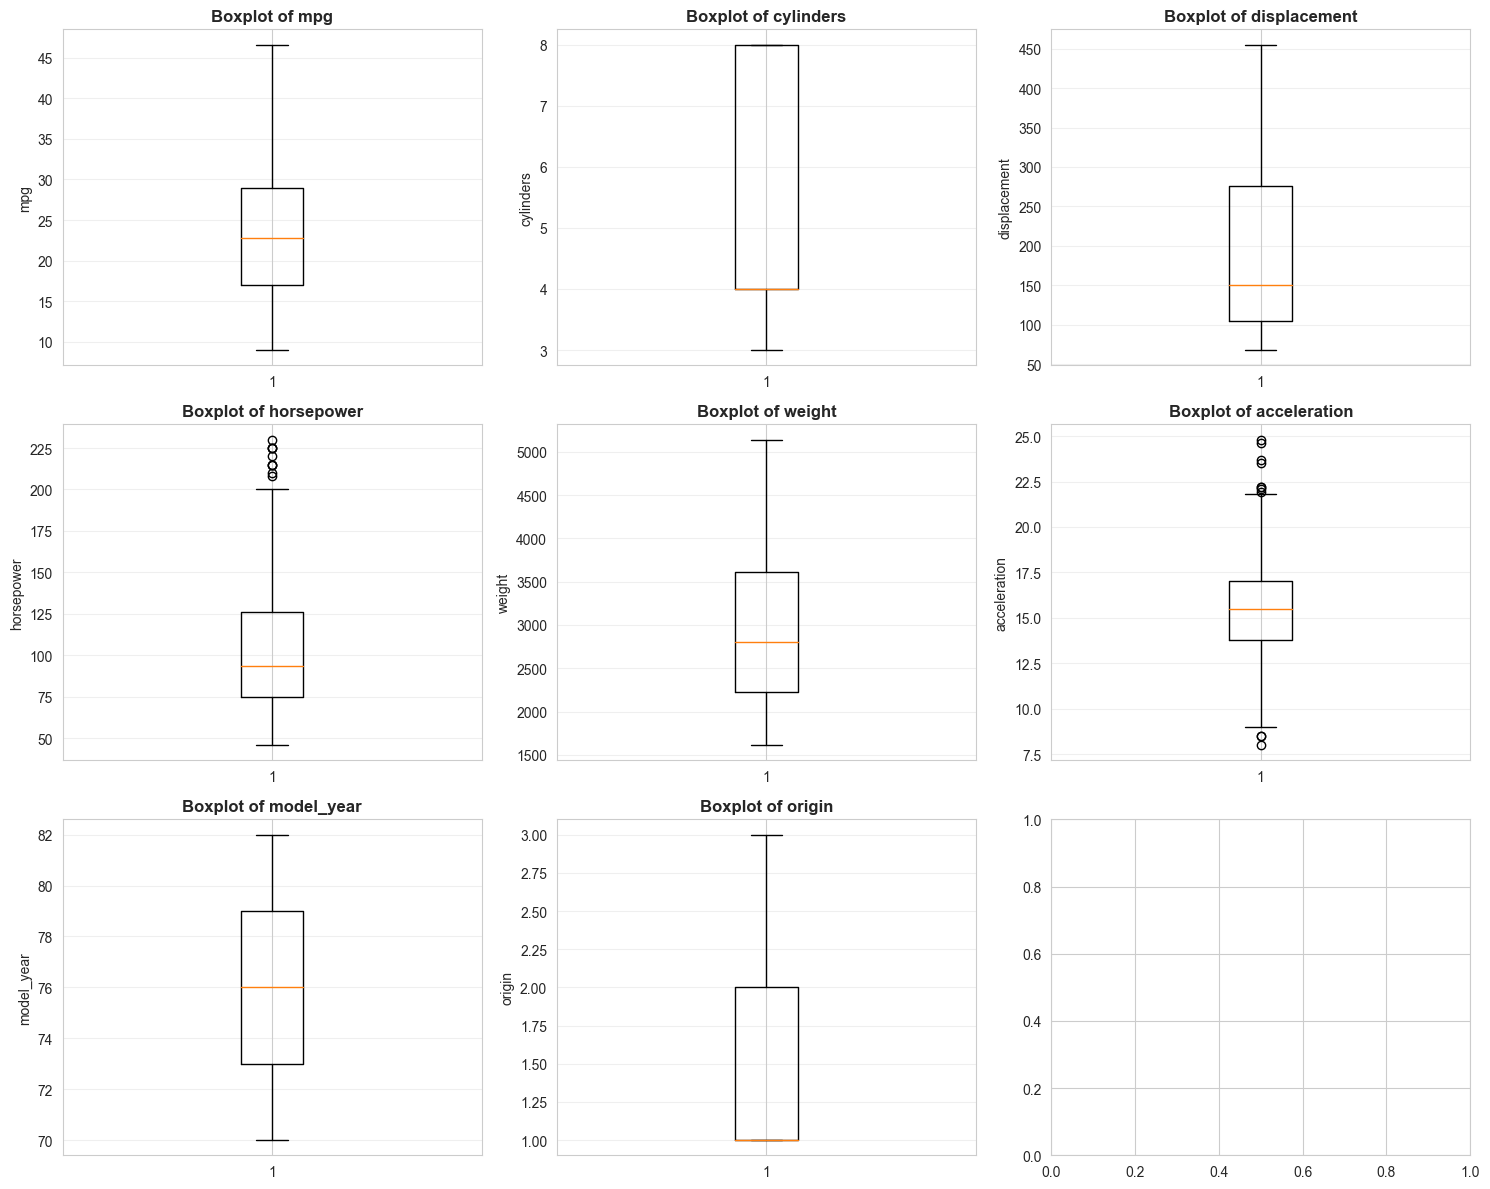


Outlier Detection (IQR method):
horsepower: 10 outliers
acceleration: 11 outliers


In [7]:
# Boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df_clean.columns):
    axes[idx].boxplot(df_clean[col], vert=True)
    axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/eda/feature_boxplots.png', dpi=300, bbox_inches='tight')
print("Saved: images/eda/feature_boxplots.png")
plt.show()

# Identify outliers using IQR method
print("\nOutlier Detection (IQR method):")
for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers")

## Step 6: Scatter Plots - MPG vs Features

Saved: images/eda/mpg_vs_features.png


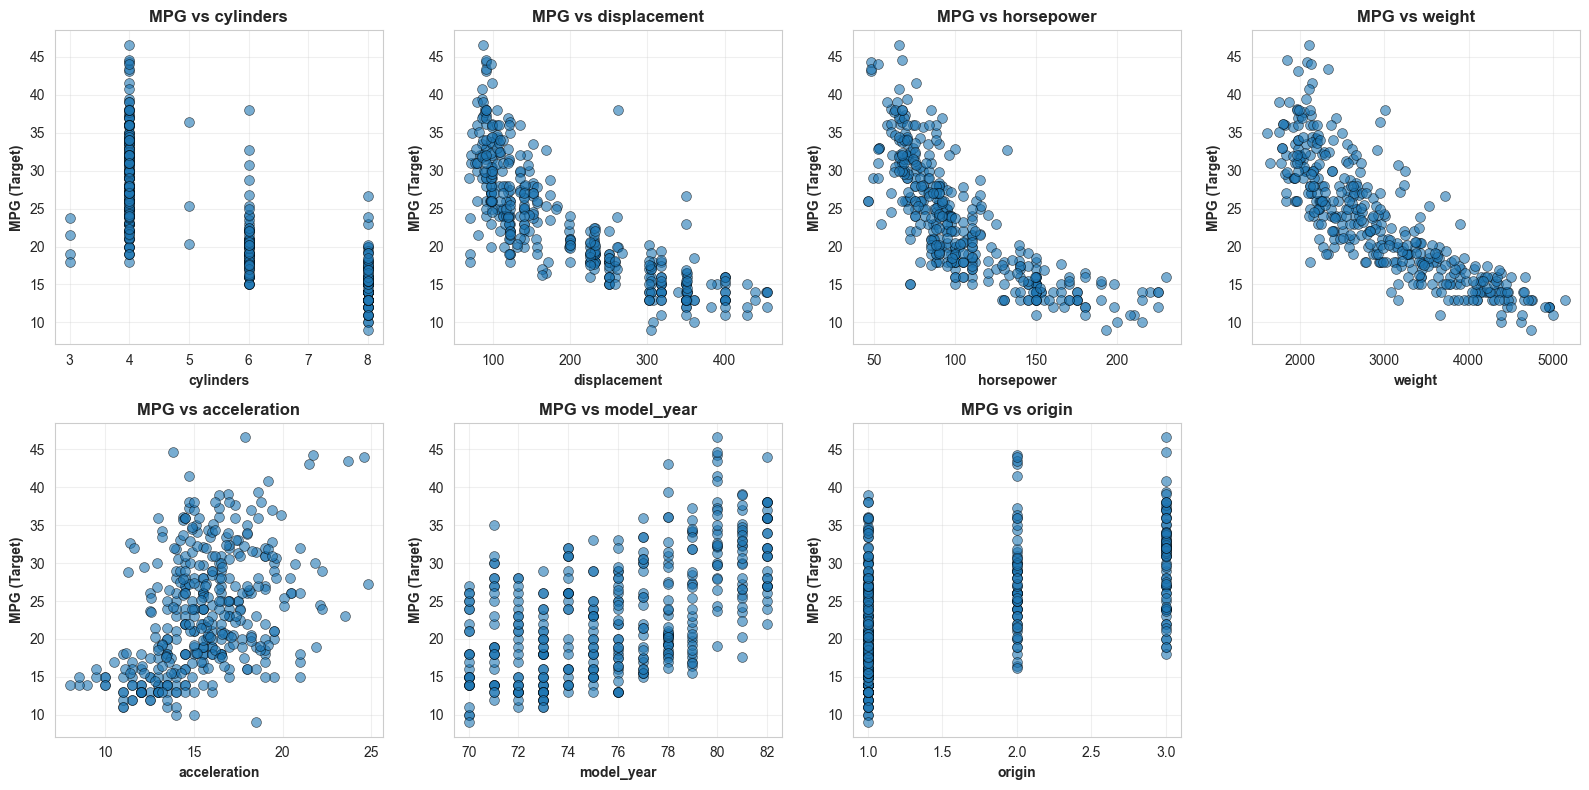

In [8]:
# Scatter plots: MPG vs each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

features_to_plot = [col for col in df_clean.columns if col != 'mpg']

for idx, col in enumerate(features_to_plot):
    axes[idx].scatter(df_clean[col], df_clean['mpg'], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('MPG (Target)', fontweight='bold')
    axes[idx].set_title(f'MPG vs {col}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

# Remove the last unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('images/eda/mpg_vs_features.png', dpi=300, bbox_inches='tight')
print("Saved: images/eda/mpg_vs_features.png")
plt.show()

## Step 7: Statistical Summary

In [9]:
# Summary statistics
print("Target Variable (MPG) Statistics:")
print(f"Mean: {df_clean['mpg'].mean():.2f}")
print(f"Median: {df_clean['mpg'].median():.2f}")
print(f"Std Dev: {df_clean['mpg'].std():.2f}")
print(f"Min: {df_clean['mpg'].min():.2f}")
print(f"Max: {df_clean['mpg'].max():.2f}")
print(f"Range: {df_clean['mpg'].max() - df_clean['mpg'].min():.2f}")
print(f"Skewness: {df_clean['mpg'].skew():.2f}")
print(f"Kurtosis: {df_clean['mpg'].kurtosis():.2f}")

print("\nFeature Statistics:")
print(df_clean.describe().T)

Target Variable (MPG) Statistics:
Mean: 23.45
Median: 22.75
Std Dev: 7.81
Min: 9.00
Max: 46.60
Range: 37.60
Skewness: 0.46
Kurtosis: -0.52

Feature Statistics:
              count         mean         std     min       25%      50%  \
mpg           392.0    23.445918    7.805007     9.0    17.000    22.75   
cylinders     392.0     5.471939    1.705783     3.0     4.000     4.00   
displacement  392.0   194.411990  104.644004    68.0   105.000   151.00   
horsepower    392.0   104.469388   38.491160    46.0    75.000    93.50   
weight        392.0  2977.584184  849.402560  1613.0  2225.250  2803.50   
acceleration  392.0    15.541327    2.758864     8.0    13.775    15.50   
model_year    392.0    75.979592    3.683737    70.0    73.000    76.00   
origin        392.0     1.576531    0.805518     1.0     1.000     1.00   

                   75%     max  
mpg             29.000    46.6  
cylinders        8.000     8.0  
displacement   275.750   455.0  
horsepower     126.000   230.0  

## Step 8: Key Insights

In [10]:
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

# Target variable insights
print("\n1. TARGET VARIABLE (MPG):")
print(f"   - Range: {df_clean['mpg'].min():.1f} to {df_clean['mpg'].max():.1f}")
print(f"   - Mean: {df_clean['mpg'].mean():.1f}")
print(f"   - Distribution: Approximately normal")

# Feature relationships
print("\n2. FEATURE RELATIONSHIPS WITH MPG:")
top_corr = correlation_matrix['mpg'].abs().sort_values(ascending=False)[1:4]
for feat, corr in top_corr.items():
    direction = "positively" if correlation_matrix.loc[feat, 'mpg'] > 0 else "negatively"
    print(f"   - {feat}: {direction} correlated ({corr:.3f})")

# Data quality
print("\n3. DATA QUALITY:")
print(f"   - Total samples: {len(df_clean)}")
print(f"   - Missing values: None")
print(f"   - All features are numeric")

# Observations for modeling
print("\n4. OBSERVATIONS FOR MODELING:")
print(f"   - Features show reasonable variation")
print(f"   - Some outliers present (weight, displacement)")
print(f"   - Different feature scales suggest need for normalization")
print(f"   - Multiple features correlate with MPG (good for prediction)")
print("="*60)


KEY INSIGHTS FROM EDA

1. TARGET VARIABLE (MPG):
   - Range: 9.0 to 46.6
   - Mean: 23.4
   - Distribution: Approximately normal

2. FEATURE RELATIONSHIPS WITH MPG:
   - weight: negatively correlated (0.832)
   - displacement: negatively correlated (0.805)
   - horsepower: negatively correlated (0.778)

3. DATA QUALITY:
   - Total samples: 392
   - Missing values: None
   - All features are numeric

4. OBSERVATIONS FOR MODELING:
   - Features show reasonable variation
   - Some outliers present (weight, displacement)
   - Different feature scales suggest need for normalization
   - Multiple features correlate with MPG (good for prediction)
